In [ ]:
import matplotlib.pyplot as plt # For plotting
import numpy as np              # Linear algebra library

In addition to using `numpy` for its linear algebra functionalities, we will also use
a library called `pandas` to help us read CSV files and manipulate tabular data.
The below code reads each of the csv files into a **data frame**, which is a way that
`pandas` stores tabular data.
As an added bonus, Jupyter notebooks display these data frames in a human-readable way.

In [ ]:
import pandas as pd
pd.set_option("display.max_rows", None)

As before, we will start by downloading the data to Google Colab.

Use pandas to read the dataset.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
def word_to_digit(sentence):
    word_to_number = {
        "one": "1",
        "two": "2",
        "three": "3",
        "four": "4",
        "five": "5",
        "six": "6",
        "seven": "7",
        "eight": "8",
        "nine": "9",
        "zero": "0",
        "ten": "10",
        "eleven": "11",
        "twelve": "12",
        "thirteen": "13",
        "fourteen": "14",
        "fifteen": "15",
        "sixteen": "16",
        "seventeen": "17",
        "eighteen": "18",
        "nineteen": "19",
        "twenty": "20"
        # Add more words as needed
    }
    for key in word_to_number:
        if key in sentence:
            return word_to_number[key]
    return sentence

In [ ]:
import re

text = "about four"

def first_number(text):
    if pd.isna(text):
        return np.nan

    text = str(text).lower()
    text = word_to_digit(text)

    # Try to extract digits first
    match = re.search(r'\d+', text)
    if match:
        return int(match.group())
    else:
      return None

first_number(text)

4

In [ ]:
def categorize_drink(drink_text):
    if pd.isna(drink_text):
        return 'none'

    drink_text = drink_text.lower().strip()

    # Specific drinks
    if 'sake' in drink_text or 'soju' in drink_text:
        return 'sake/soju'
    elif 'tea' in drink_text:
        return 'tea'
    elif 'ayran' in drink_text or 'lassi' in drink_text or 'yogurt' in drink_text:
        return 'yogurt drink'
    # elif 'coffee' in drink_text or 'espresso' in drink_text:
    #     return 'coffee'
    elif 'coke' in drink_text or 'pepsi' in drink_text or 'cola' in drink_text or 'soda' in drink_text or 'root beer' in drink_text or 'sprite' in drink_text or 'pop' in drink_text or 'ginger ale' in drink_text or 'soft drink' in drink_text or 'fanta' in drink_text:
        return 'soda'
    elif 'wine' in drink_text or 'beer' in drink_text or 'cocktail' in drink_text or 'margarita' in drink_text or 'mojito' in drink_text or 'alcohol' in drink_text:
        return 'other alcohol'
    elif 'juice' in drink_text:
        return 'juice'
    elif 'water' in drink_text:
        return 'water'
    elif 'soup' in drink_text:
        return 'soup'
    elif "don't drink" in drink_text or 'none' in drink_text or 'no drink' in drink_text:
        return 'none'
    else:
        return 'other'


categorize_drink("WaterAAAA")

'water'

In [ ]:
# read each of the csv files as a *pandas data frame*
data = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_data_combined.csv")

q2 = 'Q2: How many ingredients would you expect this food item to contain?'
q4 = 'Q4: How much would you expect to pay for one serving of this food item?'
q6 = 'Q6: What drink would you pair with this food item?'
q8 = 'Q8: How much hot sauce would you add to this food item?'
data[q8] = data[q8].replace(pd.NA, 0)
data[q8] = data[q8].replace('A little (mild)', 1)
data[q8] = data[q8].replace('A moderate amount (medium)', 2)
data[q8] = data[q8].replace('A lot (hot)', 3)
data[q8] = data[q8].replace('I will have some of this food item with my hot sauce', 4)

# replace q2 and q4 data columns with the first number that appears
data[q2] = data[q2].apply(first_number)
data[q4] = data[q4].apply(first_number)

# categorize drinks into usable data
data[q6] = data[q6].apply(categorize_drink)

# fill NaN with mean
# data[q2] = data[q2].fillna(
#     data.groupby('Label')[q2].transform('mean')
# )

# data[q4] = data[q4].fillna(
#     data.groupby('Label')[q4].transform('mean')
# )

# display one the dataframes in the notebook
data

<ipython-input-79-0750e3a04b88>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[q8] = data[q8].replace('I will have some of this food item with my hot sauce', 4)


,id,"Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)",Q2: How many ingredients would you expect this food item to contain?,Q3: In what setting would you expect this food to be served? Please check all that apply,Q4: How much would you expect to pay for one serving of this food item?,Q5: What movie do you think of when thinking of this food item?,Q6: What drink would you pair with this food item?,"Q7: When you think about this food item, who does it remind you of?",Q8: How much hot sauce would you add to this food item?,Label
0,716549,3,6.0,"Week day lunch,At a party,Late night snack",5.0,Cloudy with a Chance of Meatballs,soda,Friends,1,Pizza
1,715742,4,NaN,"Week day lunch,At a party,Late night snack",5.0,All sort of american young boy movies,soda,"Friends,Teachers,Strangers",0,Pizza
2,727333,3,5.0,"Week day lunch,Week day dinner,Weekend lunch,W...",10.0,action movie,soda,Friends,2,Pizza
3,606874,4,6.0,"Week day lunch,Week day dinner,Weekend lunch,W...",3.0,Mamma Mia,soda,"Siblings,Friends,Teachers",4,Pizza
4,505318,2,3.0,"Week day lunch,Week day dinner,Weekend lunch,W...",5.0,Cloudy with a chance of meatballs,soda,"Siblings,Friends",1,Pizza
5,605771,4,6.0,"Week day lunch,Week day dinner,Weekend lunch,W...",15.0,NaN,soda,"Siblings,Friends",0,Pizza
6,606929,3,3.0,Week day lunch,1.0,dragon,soda,Friends,0,Pizza
7,609789,4,4.0,"Week day lunch,Week day dinner,Weekend lunch,W...",20.0,Rick and Morty,soda,Friends,2,Pizza
8,644623,3,5.0,"Week day dinner,Weekend lunch,Weekend dinner,A...",3.0,Home Alone,soda,NaN,0,Pizza
9,626792,3,9.0,"Week day lunch,Week day dinner,Weekend lunch,W...",4.0,Cloudy with a chance of meatballs,soda,"Parents,Siblings,Friends",3,Pizza


In [ ]:
data['Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)'].value_counts()

,count
"Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)",
3,592
4,440
2,375
5,174
1,63


We can also visualize the spread of numerical features using *box plots*. A box plot visually summarizes much of the information that is produced by a call to data.describe(). The orange line in the middle of each box represents the median (or 50th percentile) of the data.  Each box spans a range from the 25th to 75th percentile of the attribute in question. Outliers are plotted as points outside of the box.

If, after you review some box plots, you are not comfortable with how box plots work, [Khan Academy has a good series of videos that explain how to read and interpret them.](https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data/box-whisker-plots/v/reading-box-and-whisker-plots)

<Axes: title={'center': 'Q8: How much hot sauce would you add to this food item?'}, xlabel='Label'>

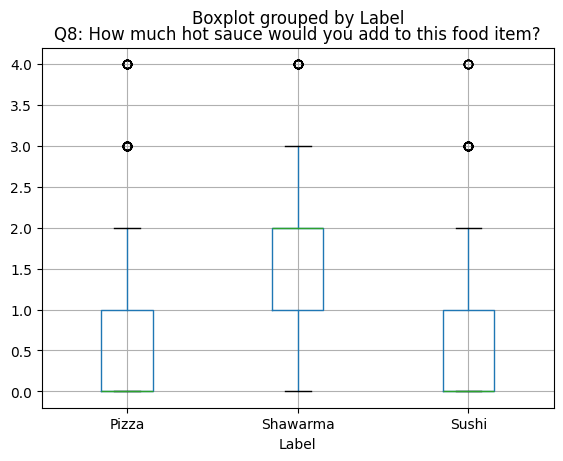

In [ ]:
# plt.title("Box Plot Showing the Distribution of 'hot sauce'")
data.boxplot(column='Q8: How much hot sauce would you add to this food item?', by='Label')

In the first box plot, we see that half of the people in the data set are under 64 kg,
just as shown in the table generated by `data.describe()`. We see also that there are some outliers who weigh more than the general population of people in our data set.


**Task:** Plot box plots for the remaining numerical features.

For the categorical features, we can also tabulate the frequency that each category
occurs in the data set:

In [ ]:
label_col = 'Label'
data_col = 'Q5: What movie do you think of when thinking of this food item?'
summary_table = data.groupby(label_col)[data_col].value_counts(dropna=False).unstack(fill_value=0)

# Find the highest count (column) per row, and sort by that value
summary_table['MaxCount'] = summary_table.max(axis=1)

# Optionally: you could also store the column name with the highest count
summary_table['TopResponse'] = summary_table.idxmax(axis=1)

# Sort by MaxCount descending
summary_table_sorted = summary_table.sort_values(by='MaxCount', ascending=False)

summary_table_sorted

Q5: What movie do you think of when thinking of this food item?,"""Naruto""","""Spider-Man: No Way Home""","""Star Wars: Episode V - The Empire Strikes Back""","""The Truman Show""",*********\nAvengers \n*********,**************\nJohnny English\n**************,-,1001 Nights,11-Sep,13 Hours,...,weathering with you,whiplash,yeh jawaani hai deewani,your name,Lost in Translation,the avengers,深夜食堂\n\nナミヤ雑貨店の奇蹟,NaN,MaxCount,TopResponse
Label,,,,,,,,,,,,,,,,,,,,,
Shawarma,0,0,1,0,1,0,1,1,1,1,...,0,0,1,0,0,0,0,32,107,The Avengers
Pizza,0,1,0,1,0,0,0,0,0,0,...,0,1,0,0,0,1,0,16,42,Home Alone
Sushi,1,0,0,0,0,1,1,0,0,0,...,1,0,0,1,1,0,1,18,21,Jiro Dreams of Sushi


In [ ]:
data['Q7: When you think about this food item, who does it remind you of?'].value_counts()

,count
"Q7: When you think about this food item, who does it remind you of?",
Friends,435
"Parents,Siblings,Friends",176
"Friends,Strangers",162
"Siblings,Friends",136
Strangers,126
"Parents,Friends",111
"Parents,Siblings",89
Parents,71
"Friends,Teachers",57


In [ ]:
data['Q6: What drink would you pair with this food item?'].value_counts()

# data2 = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/cleaned_data_combined.csv")
# data2['Q6: What drink would you pair with this food item?'].value_counts()

,count
Q6: What drink would you pair with this food item?,
soda,752
water,356
tea,247
other,82
juice,68
sake/soju,55
other alcohol,29
soup,23
yogurt drink,18


In [ ]:
# data['Q4: How much would you expect to pay for one serving of this food item?'].value_counts(dropna=False)
data['Q2: How many ingredients would you expect this food item to contain?'].value_counts(dropna=False)

,count
Q2: How many ingredients would you expect this food item to contain?,
5.0,354
4.0,243
3.0,221
6.0,178
7.0,139
10.0,134
8.0,123
2.0,70
NaN,54


In [ ]:

# Create the crosstab of drink vs. food label
drink_counts_pivot = pd.crosstab(
    data['Q6: What drink would you pair with this food item?'],
    data['Label']
)

# Sort by drink name
drink_counts_pivot = drink_counts_pivot.sort_index()

# Combine top 10 drinks per label into one summary table
top_drinks_per_label = {}

for col in drink_counts_pivot.columns:
    sorted_col = drink_counts_pivot[[col]].sort_values(by=col, ascending=False)
    top_drinks_per_label[col] = sorted_col[sorted_col[col] > 0].head(10)

# Merge the individual top-10 DataFrames into one table
combined_top_drinks = pd.concat(top_drinks_per_label.values(), axis=1)
combined_top_drinks.columns = top_drinks_per_label.keys()

# Remove index name for a cleaner display
combined_top_drinks.index.name = None

# Replace NaNs with 0
combined_top_drinks_filled = combined_top_drinks.fillna(0).astype(int)

# Optional: remove index name for cleaner header
combined_top_drinks_filled.index.name = None

# Styled display in Colab
styled_df = combined_top_drinks_filled.style.set_caption("Top Drinks by Food Label (from Q6 responses)") \
                                             .set_properties(**{'text-align': 'left'}) \
                                             .set_table_styles([{
                                                 'selector': 'th',
                                                 'props': [('text-align', 'left')]
                                             }])
styled_df


,Pizza,Shawarma,Sushi
soda,452,264,36
water,36,132,188
tea,22,48,177
other,21,32,29
juice,9,46,13
other alcohol,7,4,18
soup,1,0,22
yogurt drink,0,17,1
none,0,5,9
sake/soju,0,0,55


In [ ]:
movie_counts_pivot = pd.crosstab(
    data['Q5: What movie do you think of when thinking of this food item?'],
    data['Label']
)

# Optional: sort by movie title
movie_counts_pivot = movie_counts_pivot.sort_index()

for col in movie_counts_pivot.columns:
    print(f"\n=== Top Movies for {col.upper()} ===")
    sorted_col = movie_counts_pivot[[col]].sort_values(by=col, ascending=False)
    display(sorted_col[sorted_col[col] > 0].head(10))  # Show only non-zero counts


=== Top Movies for PIZZA ===


Label,Pizza
Q5: What movie do you think of when thinking of this food item?,
Home Alone,42
Teenage Mutant Ninja Turtles,38
Ratatouille,25
Spiderman,10
Spider-Man 2,10
Cloudy with a Chance of Meatballs,9
The Godfather,9
Cloudy with a chance of meatballs,8
spiderman,7



=== Top Movies for SHAWARMA ===


Label,Shawarma
Q5: What movie do you think of when thinking of this food item?,
The Avengers,107
Avengers,61
Aladdin,16
The Dictator,13
avengers,12
The Avengers,7
none,6
The Avengers (2012),6
Borat,6



=== Top Movies for SUSHI ===


Label,Sushi
Q5: What movie do you think of when thinking of this food item?,
Jiro Dreams of Sushi,21
Spirited Away,17
Finding Nemo,16
Kill Bill,12
Your Name,11
Monsters Inc.,9
Kung Fu Panda,8
Cars 2,7
The Wolverine,7


In [ ]:
# Create the crosstab of movies vs. food label (Q5)
movie_counts_pivot = pd.crosstab(
    data['Q5: What movie do you think of when thinking of this food item?'],
    data['Label']
)

# Sort by movie name
movie_counts_pivot = movie_counts_pivot.sort_index()

# Combine top 10 movies per label into one summary table
top_movies_per_label = {}

for col in movie_counts_pivot.columns:
    sorted_col = movie_counts_pivot[[col]].sort_values(by=col, ascending=False)
    top_movies_per_label[col] = sorted_col[sorted_col[col] > 0].head(10)

# Merge the individual top-10 DataFrames into one table
combined_top_movies = pd.concat(top_movies_per_label.values(), axis=1)
combined_top_movies.columns = top_movies_per_label.keys()

# Replace NaNs with 0 and convert to integers
combined_top_movies_filled = combined_top_movies.fillna(0).astype(int)
combined_top_movies_filled.index.name = None

# Optional: make sure index name is cleared
combined_top_movies_filled.index.name = None

# Format and display in Colab using pandas Styler
styled_movies_df = combined_top_movies_filled.style \
    .set_caption("Top Movies by Food Label (from Q5 responses)") \
    .set_properties(**{'text-align': 'left'}) \
    .set_table_styles([{
        'selector': 'th',
        'props': [('text-align', 'left')]
    }]) \
    .format("{:.0f}")  # removes decimals

styled_movies_df


,Pizza,Shawarma,Sushi
Home Alone,42,0,0
Teenage Mutant Ninja Turtles,38,0,0
Ratatouille,25,4,0
Spiderman,10,0,0
Spider-Man 2,10,0,0
Cloudy with a Chance of Meatballs,9,0,0
The Godfather,9,0,0
Cloudy with a chance of meatballs,8,0,0
spiderman,7,0,0
Home alone,7,0,0


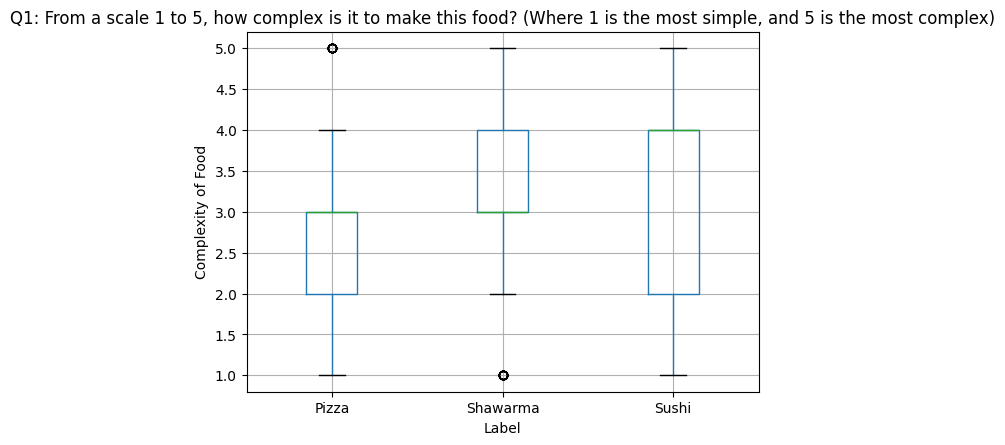

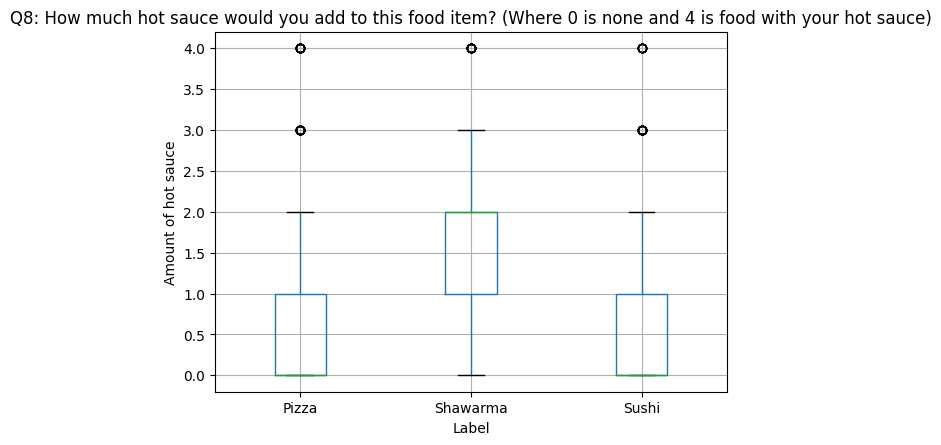

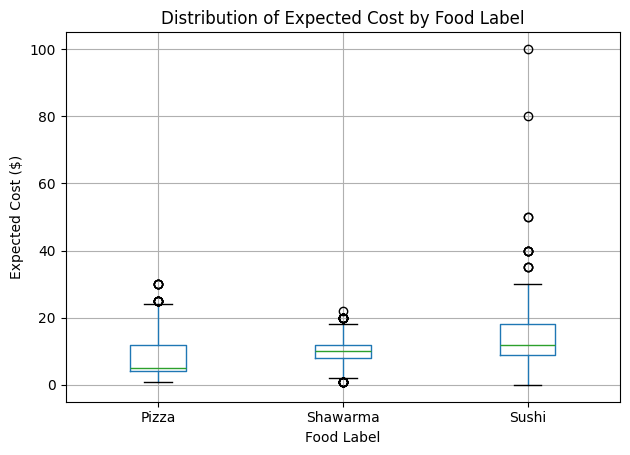

In [ ]:
# analyze the distribution of blood_cholesterol for people with and without heart disease
data.boxplot(column='Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)', by='Label')
plt.suptitle("")
plt.ylabel("Complexity of Food")

# TODO do the same for 'age', 'calories', and 'BMI'
data.boxplot(column='Q8: How much hot sauce would you add to this food item?', by='Label')
plt.suptitle("")
plt.title("Q8: How much hot sauce would you add to this food item? (Where 0 is none and 4 is food with your hot sauce)")
plt.ylabel("Amount of hot sauce")

cost_col = "Q4: How much would you expect to pay for one serving of this food item?"

# Convert to numeric in case it's not already
data[cost_col] = pd.to_numeric(data[cost_col], errors='coerce')

# Create the boxplot grouped by 'Label'
data.boxplot(column=cost_col, by='Label')

# Customize the plot
plt.suptitle("")  # Remove default grouped-by subtitle
plt.title("Distribution of Expected Cost by Food Label")
plt.xlabel("Food Label")
plt.ylabel("Expected Cost ($)")
plt.tight_layout()
plt.show()

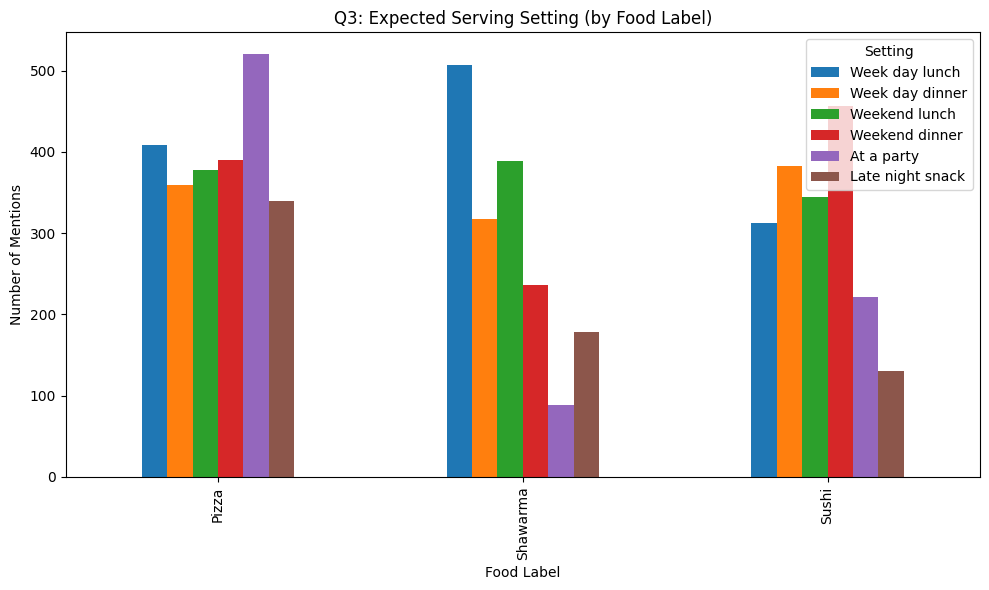

In [ ]:
# Define the column and categories for Q3
q3_col = "Q3: In what setting would you expect this food to be served? Please check all that apply"
q3_categories = [
    "Week day lunch",
    "Week day dinner",
    "Weekend lunch",
    "Weekend dinner",
    "At a party",
    "Late night snack"
]

# Initialize count dictionary
label_groups_q3 = data.groupby("Label")
label_counts_q3 = {label: {cat: 0 for cat in q3_categories} for label in label_groups_q3.groups.keys()}

# Count occurrences
for label, group in label_groups_q3:
    for cat in q3_categories:
        label_counts_q3[label][cat] = group[q3_col].str.contains(cat, na=False).sum()

# Convert to DataFrame for plotting
q3_counts_df = pd.DataFrame(label_counts_q3).T  # Labels as rows, categories as columns

# Plot
q3_counts_df.plot(kind='bar', figsize=(10, 6))
plt.title("Q3: Expected Serving Setting (by Food Label)")
plt.xlabel("Food Label")
plt.ylabel("Number of Mentions")
plt.legend(title="Setting")
plt.tight_layout()
plt.show()


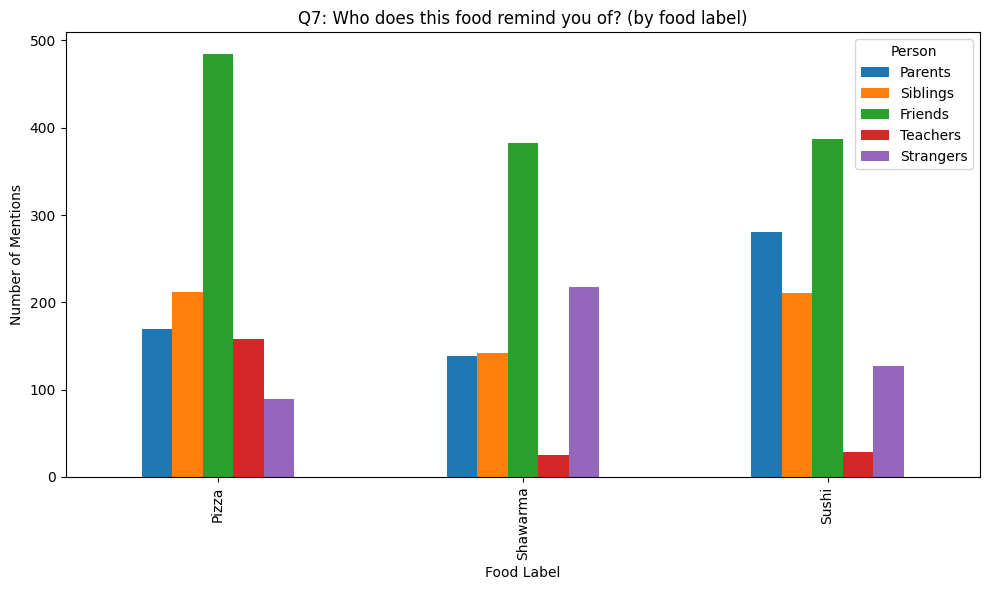

In [ ]:
import matplotlib.pyplot as plt

# Define the column and possible categories
q7_col = "Q7: When you think about this food item, who does it remind you of?"
categories = ["Parents", "Siblings", "Friends", "Teachers", "Strangers"]

# Initialize count dictionary
label_groups = data.groupby("Label")
label_counts = {label: {cat: 0 for cat in categories} for label in label_groups.groups.keys()}

# Count occurrences
for label, group in label_groups:
    for cat in categories:
        label_counts[label][cat] = group[q7_col].str.contains(cat, na=False).sum()

# Convert to DataFrame for plotting
counts_df = pd.DataFrame(label_counts).T  # Labels as rows, categories as columns

# Plot
counts_df.plot(kind='bar', figsize=(10, 6))
plt.title("Q7: Who does this food remind you of? (by food label)")
plt.xlabel("Food Label")
plt.ylabel("Number of Mentions")
plt.legend(title="Person")
plt.tight_layout()
plt.show()


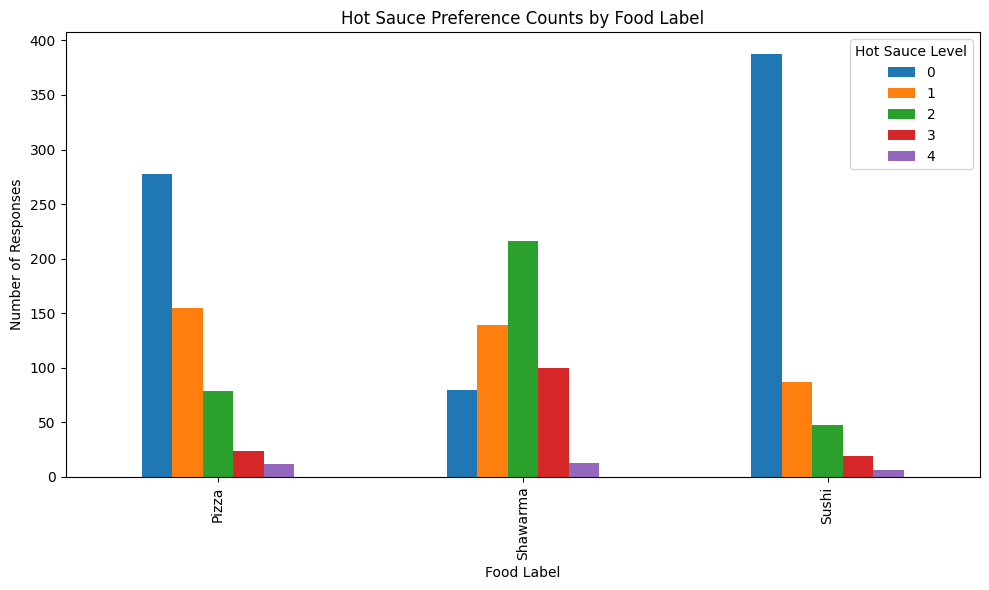

In [ ]:
# Column for hot sauce
hot_sauce_col = "Q8: How much hot sauce would you add to this food item?"

# Ensure it's numeric
data[hot_sauce_col] = pd.to_numeric(data[hot_sauce_col], errors='coerce')

# Group by Label and Hot Sauce level, then count
hot_sauce_counts = data.groupby(['Label', hot_sauce_col]).size().unstack(fill_value=0)

# Plot as a bar chart
hot_sauce_counts.plot(kind='bar', figsize=(10, 6))

# Customize the plot
plt.title("Hot Sauce Preference Counts by Food Label")
plt.xlabel("Food Label")
plt.ylabel("Number of Responses")
plt.legend(title="Hot Sauce Level")
plt.tight_layout()
plt.show()


In [ ]:
pd.crosstab(data["Q5: What movie do you think of when thinking of this food item?"], data["Label"])

Label,Pizza,Shawarma,Sushi
Q5: What movie do you think of when thinking of this food item?,,,
"""Naruto""",0,0,1
"""Spider-Man: No Way Home""",1,0,0
"""Star Wars: Episode V - The Empire Strikes Back""",0,1,0
"""The Truman Show""",1,0,0
*********\nAvengers \n*********,0,1,0
**************\nJohnny English\n**************,0,0,1
-,0,1,1
1001 Nights,0,1,0
11-Sep,0,1,0


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

# Step 1: Extract and clean the movie column
movie_texts = data["Q5: What movie do you think of when thinking of this food item?"].fillna("")

# Step 2: Convert to Bag-of-Words
vectorizer = CountVectorizer()
X_bow = vectorizer.fit_transform(movie_texts)

# Convert to DataFrame for visualization
bow_df = pd.DataFrame(X_bow.toarray(), columns=vectorizer.get_feature_names_out())

# Display shape and a preview
bow_df_shape = bow_df.shape
bow_df_preview = bow_df.head()

bow_df_shape, bow_df_preview

((1644, 982),
    007  10  1001  11  13  1953  2001  2002  2004  2005  ...  you  young  your  \
 0    0   0     0   0   0     0     0     0     0     0  ...    0      0     0   
 1    0   0     0   0   0     0     0     0     0     0  ...    0      1     0   
 2    0   0     0   0   0     0     0     0     0     0  ...    0      0     0   
 3    0   0     0   0   0     0     0     0     0     0  ...    0      0     0   
 4    0   0     0   0   0     0     0     0     0     0  ...    0      0     0   
 
    za  zodiac  zohan  zootopia  ナミヤ雑貨店の奇蹟  一休さん  深夜食堂  
 0   0       0      0         0          0     0     0  
 1   0       0      0         0          0     0     0  
 2   0       0      0         0          0     0     0  
 3   0       0      0         0          0     0     0  
 4   0       0      0         0          0     0     0  
 
 [5 rows x 982 columns])

In [ ]:
food_complexity = "Q1: From a scale 1 to 5, how complex is it to make this food? (Where 1 is the most simple, and 5 is the most complex)"

setting = "Q3: In what setting would you expect this food to be served? Please check all that apply"
drinks = "Q6: What drink would you pair with this food item?"
person = "Q7: When you think about this food item, who does it remind you of?"
hot_sauce = "Q8: How much hot sauce would you add to this food item?"
data_fets = np.stack([
    # 5 choices for food complexity
    data[food_complexity] == 1,
    data[food_complexity] == 2,
    data[food_complexity] == 3,
    data[food_complexity] == 4,
    data[food_complexity] == 5,

    # 5 choices for hot sauce
    data[hot_sauce] == 0,
    data[hot_sauce] == 1,
    data[hot_sauce] == 2,
    data[hot_sauce] == 3,
    data[hot_sauce] == 4,

    # 7 categories, for each type of setting including None
    data[setting].str.contains("Week day lunch", na=False).astype(int),
    data[setting].str.contains("Week day dinner", na=False).astype(int),
    data[setting].str.contains("Weekend lunch", na=False).astype(int),
    data[setting].str.contains("Weekend dinner", na=False).astype(int),
    data[setting].str.contains("At a party", na=False).astype(int),
    data[setting].str.contains("Late night snack", na=False).astype(int),
    data[setting] == pd.NA,

    # 6 categories for each type of person and None
    data[person].str.contains("Parents", na=False).astype(int),
    data[person].str.contains("Siblings", na=False).astype(int),
    data[person].str.contains("Friends", na=False).astype(int),
    data[person].str.contains("Teachers", na=False).astype(int),
    data[person].str.contains("Strangers", na=False).astype(int),
    data[person] == pd.NA,

    # 10 categories for drinks
    data[drinks].str.contains("soda", na=False).astype(int),
    data[drinks].str.contains("water", na=False).astype(int),
    data[drinks].str.contains("tea", na=False).astype(int),
    data[drinks].str.contains("other", na=False).astype(int),
    data[drinks].str.contains("juice", na=False).astype(int),
    data[drinks].str.contains("asian alcohol", na=False).astype(int),
    data[drinks].str.contains("other alcohol", na=False).astype(int),
    data[drinks].str.contains("soup", na=False).astype(int),
    data[drinks].str.contains("yogurt drink", na=False).astype(int),
    data[drinks].str.contains("none", na=False).astype(int),

    # numerical features
    data["Q2: How many ingredients would you expect this food item to contain?"],
    data["Q4: How much would you expect to pay for one serving of this food item?"]
], axis=1)

# Convert sparse BoW to dense (only if memory permits)
bow_dense = X_bow.toarray()

# Sanity check: shapes should align on axis 0
assert data_fets.shape[0] == bow_dense.shape[0]

# Concatenate along columns (axis=1)
data_fets = np.concatenate([bow_dense, data_fets], axis=1)

# Confirm shape
print("Combined feature shape:", data_fets.shape)


print(data_fets.shape) # Should be (1644, 35)

Combined feature shape: (1644, 1017)
(1644, 1017)


In [ ]:
feature_names = [
    "Not complex",
    "Slightly complex",
    "Moderately complex",
    "Pretty complex",
    "Very complex",
    "No hot sauce",
    "A bit of hot sauce",
    "A moderate amount of hot sauce",
    "A lot of hot sauce",
    "Food? Only hot sauce",
    "Week day lunch",
    "Week day dinner",
    "Weekend lunch",
    "Weekend dinner",
    "At a party",
    "Late night snack",
    "No setting",
    "Parents",
    "Siblings",
    "Friends",
    "Teachers",
    "Strangers",
    "Nobody",
    "soda",
    "water",
    "tea",
    "other",
    "juice",
    "asian alcohol",
    "other alcohol",
    "soup",
    "yogurt drink",
    "none",
    "number of ingredients",
    "cost"
    ]

  # Get the BoW feature names
bow_feature_names = vectorizer.get_feature_names_out()

# Combine the two
feature_names = list(bow_feature_names) + feature_names

# Show total count and a preview
len(feature_names), feature_names[:40], feature_names[-10:]

(1017,
 ['007',
  '10',
  '1001',
  '11',
  '13',
  '1953',
  '2001',
  '2002',
  '2004',
  '2005',
  '2006',
  '2008',
  '2012',
  '2014',
  '2016',
  '2018',
  '2021',
  '2022',
  '2024',
  '21',
  '30',
  '3d',
  '47',
  '85',
  'about',
  'abyss',
  'academia',
  'across',
  'action',
  'actually',
  'advengers',
  'after',
  'again',
  'age',
  'air',
  'aladdin',
  'alien',
  'aliens',
  'alita',
  'all'],
 ['tea',
  'other',
  'juice',
  'asian alcohol',
  'other alcohol',
  'soup',
  'yogurt drink',
  'none',
  'number of ingredients',
  'cost'])

**Task** Finally, let's separate our data into training, validation, and test sets.
We will use 5000 data points for training, 1500 for validation, and 1500 for test.

Instead of manually splitting the data into two sets, we will use a function provided by `sklearn` which randomly splits the data for us. Use the `train_test_split` function to split the data into training and test sets. To ensure that the randomization is consistent across runs, please supply the following parameter to the `train_test_split` function: 'random_state=1'.  This will ensure that the each time you run your code, you are placing the same data points in your training, test and validation sets.

You will likely need to read the [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) for the `sklearn.model_selection.train_test_splits` to get this job done.

In [ ]:

from sklearn.model_selection import train_test_split

# Split the data into X (dependent variables) and t (response variable)
X = data_fets
t = np.array(data["Label"])

# First, we will use `train_test_split` to split the data set into
# 6500 training+validation, and 1500 test:
X_tv, X_test, t_tv, t_test = train_test_split(X, t, test_size=274/1644, random_state=1)

# Then, use `train_test_split` to split the training+validation data
# into 5000 train and 1500 validation
X_train, X_valid, t_train, t_valid = train_test_split(X_tv, t_tv, test_size=274/1370, random_state=1)
print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(1096, 1017)
(274, 1017)
(274, 1017)


## Part 2. Using `sklearn` to Implement and Visualize Decision Trees

One advantage of decision trees over other models is that they are easy
to interpret and visualize.  The function `visualize_tree` below can be used to plot an `sklearn` decision tree model in your Colab Notebook.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# imports to visualize tree
from sklearn import tree as treeViz
import graphviz
import pydotplus
from IPython.display import display

In [ ]:
def visualize_tree(model, max_depth=5):
    """
    Generate and return an image representing an Sklearn decision tree.

    Each node in the visualization represents a node in the decision tree.
    In addition, visualization for each node contains:
        - The feature that is split on
        - The entropy (of the outputs `t`) at the node
        - The number of training samples at the node
        - The number of training samples with true/false values
        - The majority class (heart disease or not)
    The colour of the node also shows the majority class and purity

    See here: https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html

    Parameters:
        `model` - An Sklearn decision tree model
        `max_depth` - Max depth of decision tree to be rendered in the notebook.
         This is useful since the tree can get very large if the max_depth is
         set too high and thus making the resulting figure difficult to interpret.
    """
    dot_data = treeViz.export_graphviz(model,
                                       feature_names=feature_names,
                                       max_depth=max_depth,
                                       class_names=["sushi", "pizza", "shawarma"],
                                       filled=True,
                                       rounded=True)
    return display(graphviz.Source(dot_data))


Next, we will use sklearn's `DecisionTreeClassifier` to create some decision trees to fit to our data.

**Task:** Fit a `DecisionTreeClassifier` to our dataset. Use `entropy` to measure the quality of a decision tree split, and set the `max_depth` to 3. Then, print the training and validation scores (accuracy).

See more here: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [ ]:
# Creating a DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion="entropy", max_depth=5)

# TODO: fit it to our data
tree.fit(X_train, t_train)

# Print the training and validation scores (accuracy)
print("Training Accuracy:", tree.score(X_train, t_train))
print("Validation Accuracy:", tree.score(X_valid, t_valid))

Training Accuracy: 0.8786496350364964
Validation Accuracy: 0.8065693430656934


**Task:** Use `visualize_tree` to visualize the decision tree that was fit.

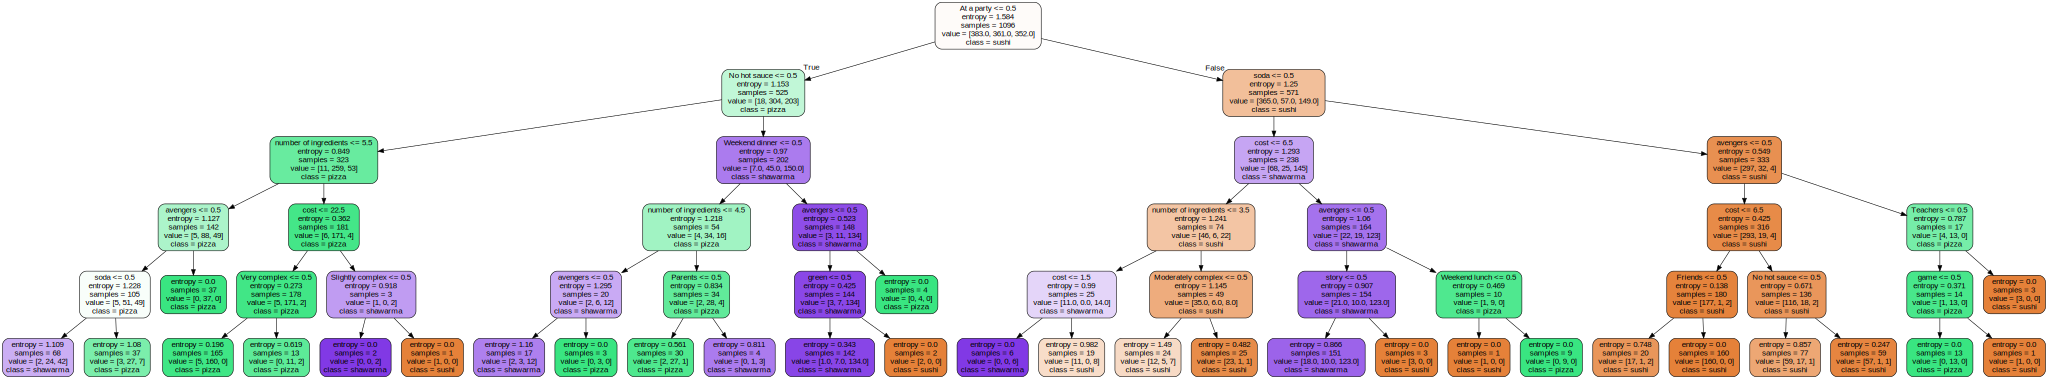

In [ ]:
# TODO: call visualize_tree on the tree that was fit
visualize_tree(tree)

We will now explore some hyperparameter choices that may cause our decision tree to underfit or overfit our data. Recall that overfitting means that, while our model may accurately capture relationships between inputs and our classification target in training data, it may not capture such relationships in the validation data. By contrast, underfitting occurs when our model lacks the complexity to model relationships in either training or validation data.  

**Task:** Similar to what you did above, create another `DecisionTreeClassifier` that uses `entropy` to measure the quality of a split. Set the `max_depth` to a value that will cause the tree to *underfit*. Report the accuracy on the validation and training sets. Visualize the tree by calling `visualize_tree`.

Training Accuracy: 0.8786496350364964
Validation Accuracy: 0.8065693430656934


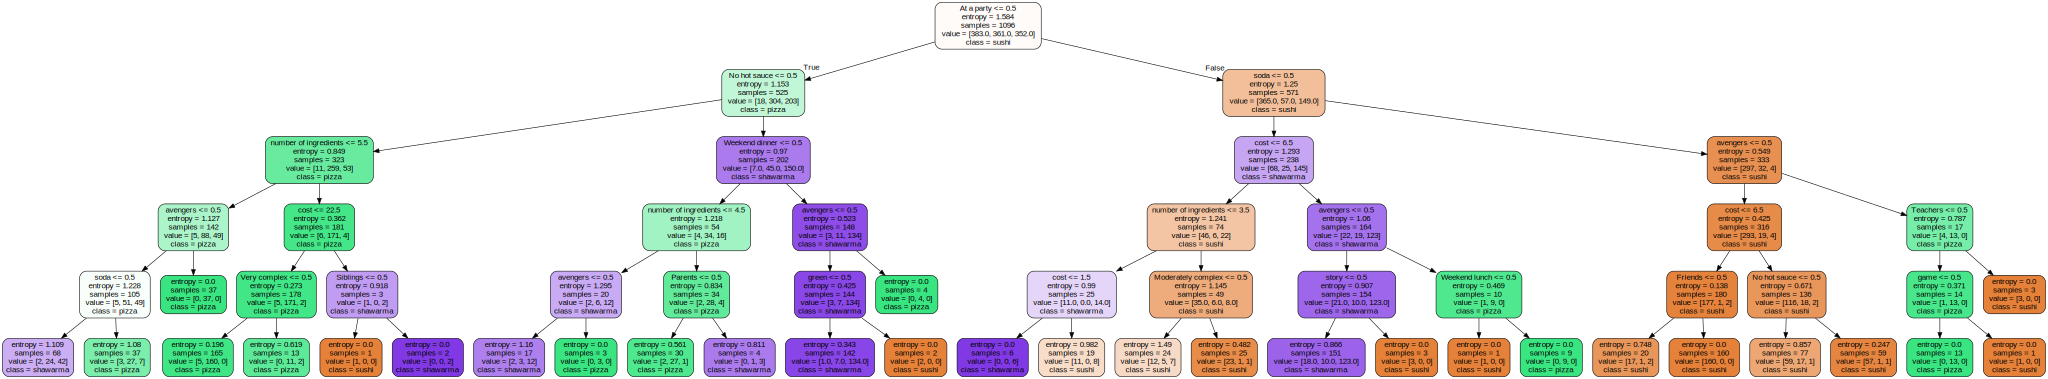

In [ ]:
# TODO: create a DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion="entropy", max_depth=5)

# TODO: fit it to our data
tree.fit(X_train, t_train)

# Print the training and validation accuracy
print("Training Accuracy:", tree.score(X_train, t_train))
print("Validation Accuracy:", tree.score(X_valid, t_valid))

# TODO: visualize the tree
visualize_tree(tree)

We will now repeat the same computation as above, but vary the `min_samples_split` parameter instead of `max_depth`.

**Task:** Similar to what we've been doing above, create another `DecisionTreeClassifier` that uses `entropy` to measure the quality of a split. This time set `min_samples_split` to a value that would cause the tree to *underfit*.  Omit the `max_depth` parameter. Report the accuracy (obtained via the `score()` method) on the validation and training sets. Visualize the tree.

Training Accuracy: 0.8932481751824818
Validation Accuracy: 0.8138686131386861


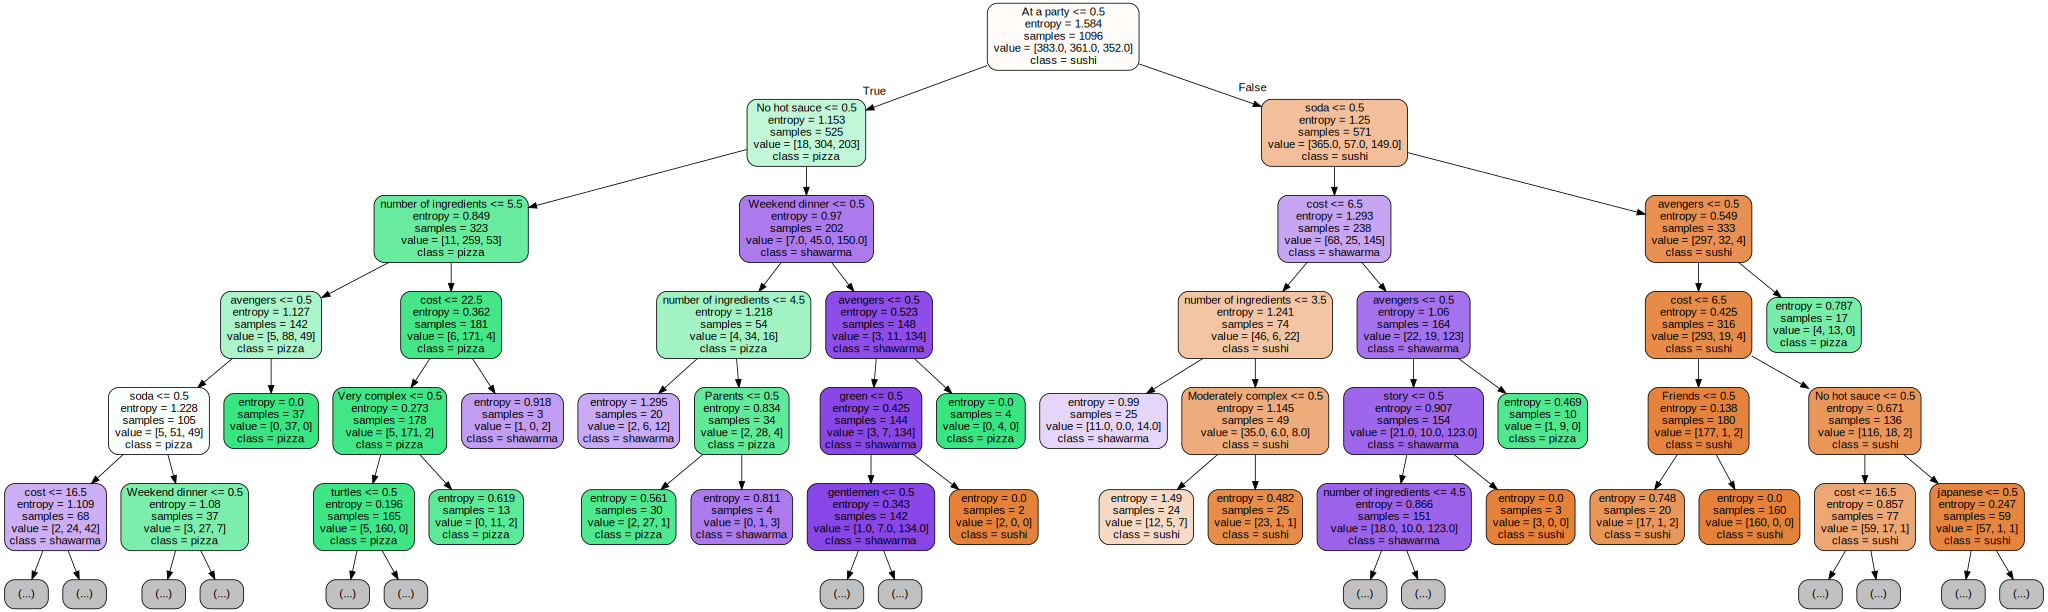

In [ ]:
# TODO
tree = DecisionTreeClassifier(criterion="entropy", min_samples_split=32)

# TODO: fit it to our data
tree.fit(X_train, t_train)

# Print the training and validation accuracy
print("Training Accuracy:", tree.score(X_train, t_train))
print("Validation Accuracy:", tree.score(X_valid, t_valid))

# TODO: visualize the tree
visualize_tree(tree)

## Part 3. Hyperparameter Tuning

So far, we have experimented with two Decision Tree hyperparameters: `max_depth` and `min_samples_split`. Another hyperparameter we can vary is the `criterion` for measuring split quality. In lecture, and earlier in this lab, we used `entropy` as the criterion. Another criterion that Sklearn supports is `gini` (Gini impurity index). You don't need to know the implementation details behind this as we'll rely on Sklearn to compute it. However, if you are interested in learning more about this alternative impurity index, we encourage you to [read more about it](https://en.wikipedia.org/wiki/Gini_coefficient).

Thus, our goal is now to figure out what combination of `max_depth`, `min_samples_split` and `criterion` results in the "best" decision tree. It is up to you to determine what "best" means in this context.

**Graded Task:** Start by completing `build_all_models` based on the function specification.
This function builds many trees, one for each combination of hyperparameters, and
then compares them.

In [ ]:
def build_all_models(max_depths,
                     min_samples_split,
                     criterion,
                     X_train=X_train,
                     t_train=t_train,
                     X_valid=X_valid,
                     t_valid=t_valid):
    """
    Parameters:
        `max_depths` - A list of values representing the max_depth values to be
                       try as hyperparameter values
        `min_samples_split` - An list of values representing the min_samples_split
                       values to try as hyperpareameter values
        `criterion` -  A string; either "entropy" or "gini"

    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    In other words, out[(max_depth, min_samples_split)]['val'] = validation score and
                    out[(max_depth, min_samples_split)]['train'] = training score
    For that combination of (max_depth, min_samples_split) hyperparameters.
    """
    out = {}

    for d in max_depths:
        for s in min_samples_split:
            out[(d, s)] = {}
            # Create a DecisionTreeClassifier based on the given hyperparameters and fit it to the data
            tree = DecisionTreeClassifier(criterion=criterion, max_depth=d, min_samples_split=s,  random_state=1) # TODO
            tree.fit(X_train, t_train)

            # TODO: store the validation and training scores in the `out` dictionary
            out[(d, s)]['val'] = tree.score(X_valid, t_valid) # TODO
            out[(d, s)]['train'] = tree.score(X_train, t_train) # TODO
    return out

**Graded Task:** In this task, we will use an approach called **grid search** to
tune hyperparameters: we will list possible values for each hyperparameter,
and then attempt every combination of hyperparameter choices. In our case,
we will start with some possible values for `max_depth`, `min_samples_split` and `criterion`. Then we will try all combinations
of these hyperparameter choices.

Complete the code below that performs grid search, by using `build_all_models`
to build models and evaluate hyperparameter choices.
Print the best parameters and corresponding scores (accuracy) for each of
criterion=entropy and criterion=gini (i.e. you should have 2 print statements, 1 for each criterion).

In [ ]:
# Hyperparameters values to try in our grid search
criterions = ["entropy", "gini"]
max_depths = [1, 5, 10, 15, 20, 25, 30, 50, 100]
min_samples_split = [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

for criterion in criterions:
    print("\nUsing criterion {}".format(criterion))
    res = build_all_models(max_depths, min_samples_split, criterion) # TODO: call `build_all_models` for the given hyperparameters

    # TODO: complete this loop which should search for the optimal
    #  (max_depth, min_samples_split) given this criterion
    best = 0
    for d, s in res:
      # print("Train Accuracy:", res[d, s]['train'])
      # print("Val Accuracy:", res[d,s]['val'])

      # Choose the best hyperparameters by validation accuracy
      if res[d, s]['val'] > best:
        best = res[d, s]['val']
        hyperparams = (d, s)

    print("best depth:", hyperparams[0])
    print("best samples split:", hyperparams[1])
    print("Val Accuracy:", best)




Using criterion entropy
best depth: 5
best samples split: 32
Val Accuracy: 0.8211678832116789

Using criterion gini
best depth: 5
best samples split: 32
Val Accuracy: 0.8321167883211679


## Part 4. Test accuracy

**Task:** Use the optimal set of hyperparameters you previously discovered to fit a new Decision Tree model to the data. Report the test score.

In [ ]:
best_tree = DecisionTreeClassifier(criterion="entropy", max_depth=5, min_samples_split=32) # TODO
best_tree.fit(X_train, t_train)

print("Test Accuracy:", best_tree.score(X_test, t_test))



Test Accuracy: 0.8722627737226277
